# Underfitting Model

by Niklas Vogel and Kevin Stupar

## Setup
This notebook creates an underfitting model and evaluates it.

Before executing this please make sure you did download and extract the data using an unzip tool optimized for your OS (`unzip` in WSL could take a long time)
The Download can be done using `setup.sh`

## Data Credit
TODO

# Load the data and split it

In [4]:
from helper import get_data, plot_accuracy_and_loss, plot_confusion_matrix, plot_samples, plot_number_per_class, calculate_predictions, plot_scores
from keras import layers, models

image_size = (64, 64)

(all_images, train_images, validation_images, test_images, label_names) = get_data(image_size)

Number of training images:  9043
Number of validation images:  2260
Number of testing images:  4845
Class names:  ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.

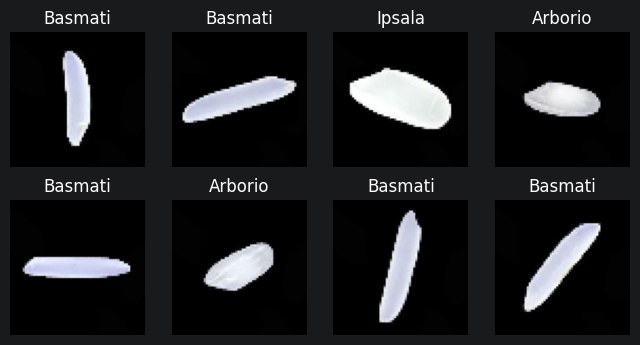

In [5]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 4000 images, except for Karacadag, which only has 150 images.
This should lead to a worse performance of this class.

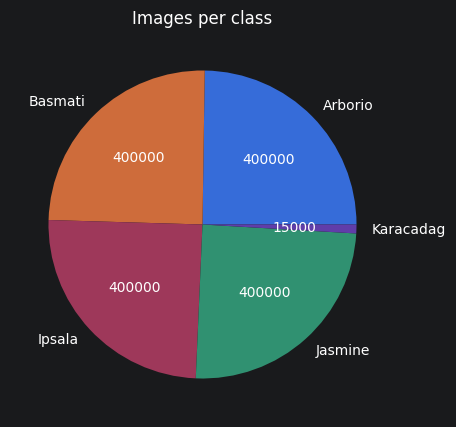

In [6]:
plot_number_per_class(all_images, label_names)

# Building the model

We want an underfitting model, so we will only use two convolutional layers and apply string max-pooling to reduce the numver of parameters.

Since the Images need to have a rather high resolution (64x64), we have nearly 2000 parameters, since else the model would perform very poorly.

In [7]:
model = models.Sequential([
    layers.Input(shape=image_size +(3,)),
    layers.Rescaling(1./255),
    layers.Conv2D(16, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(8, (3,3), activation="relu"),
    layers.MaxPooling2D((8,8)),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,973 (7.71 KB)

 Trainable params: 1,973 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training the model

Now we need to compile and train the model, which could take some time.

In [8]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model.fit(train_images, epochs=30, validation_data=validation_images)

Epoch 1/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6577 - loss: 0.8844 - val_accuracy: 0.8584 - val_loss: 0.4216
Epoch 2/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9273 - loss: 0.2574 - val_accuracy: 0.9469 - val_loss: 0.1880
Epoch 3/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9507 - loss: 0.1647 - val_accuracy: 0.9540 - val_loss: 0.1469
Epoch 4/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9570 - loss: 0.1375 - val_accuracy: 0.9673 - val_loss: 0.1152
Epoch 5/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9627 - loss: 0.1217 - val_accuracy: 0.9584 - val_loss: 0.1248
Epoch 6/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9675 - loss: 0.1044 - val_accuracy: 0.9642 - val_loss: 0.1136
Epoch 7/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9674 - loss: 0.1030 - val_accuracy: 0.9735 - val_loss: 0.0885
Epoch 8/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9654 - loss: 0.1011 - val_accuracy: 0.

# Evaluating the model

Using a few plot we can see, that the model is underfitting.
Note that the loss is on a log scale to be able to interpret the results better.

In [9]:
true, pred = calculate_predictions(model, test_images)

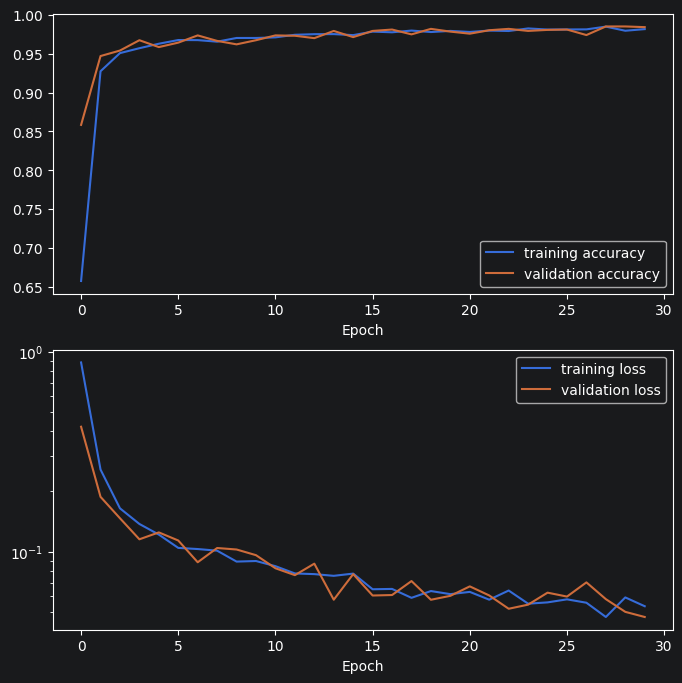

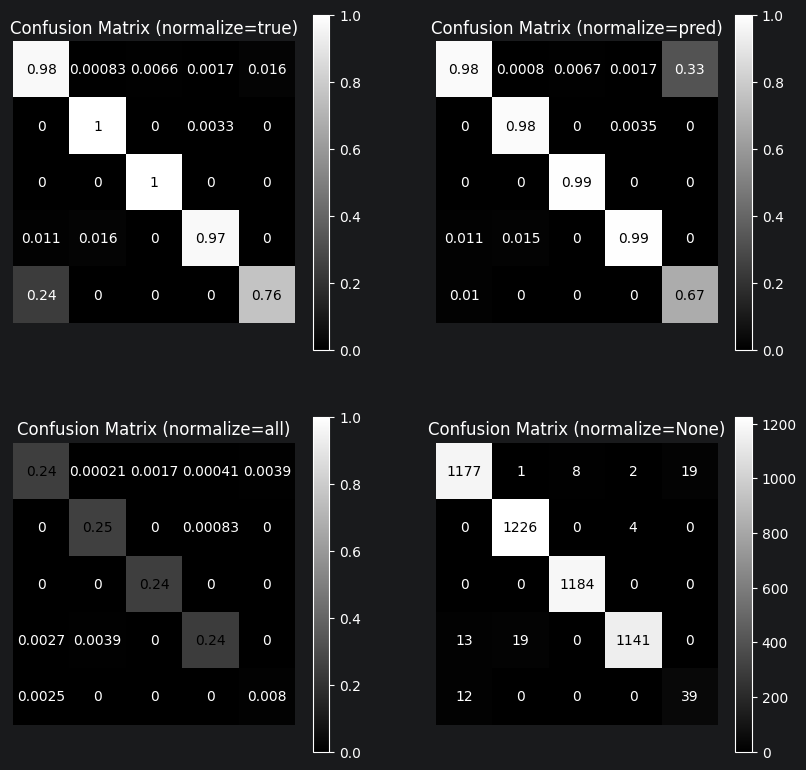

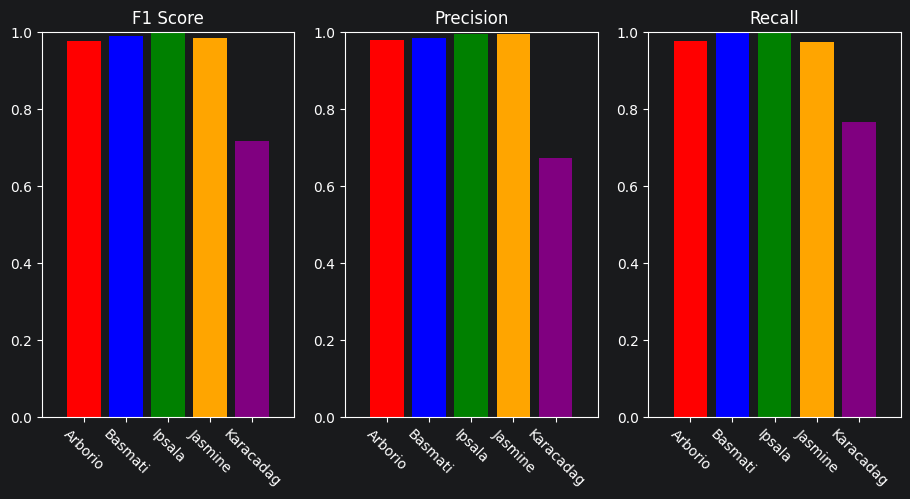

In [10]:
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])

plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)